In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv("superstore.csv", encoding="latin-1")
print("Dataset loaded!")
print(df.shape)  # shows rows and columns

Dataset loaded!
(9994, 21)


In [3]:
df.head()  # shows first 5 rows

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.isnull().sum()  # shows if any column has missing data

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
df.info()  # shows column names, data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [13]:

df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df["Month"] = df["Order Date"].dt.to_period("M")
print("Date column fixed!")


Date column fixed!


In [16]:
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()
monthly_sales["Month"] = monthly_sales["Month"].astype(str)
print('these months have the highest sales')
print(monthly_sales.sort_values("Sales", ascending=False).head(5))

these months have the highest sales
      Month        Sales
46  2017-11  118447.8250
35  2016-12   96999.0430
44  2017-09   87866.6520
47  2017-12   83829.3188
8   2014-09   81777.3508


In [17]:
category_sales = df.groupby("Category")["Sales"].sum().reset_index()
print(category_sales)

          Category        Sales
0        Furniture  741999.7953
1  Office Supplies  719047.0320
2       Technology  836154.0330


In [18]:
region_sales = df.groupby("Region")["Sales"].sum().reset_index()
print(region_sales.sort_values("Sales", ascending=False))

    Region        Sales
3     West  725457.8245
1     East  678781.2400
0  Central  501239.8908
2    South  391721.9050


In [19]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

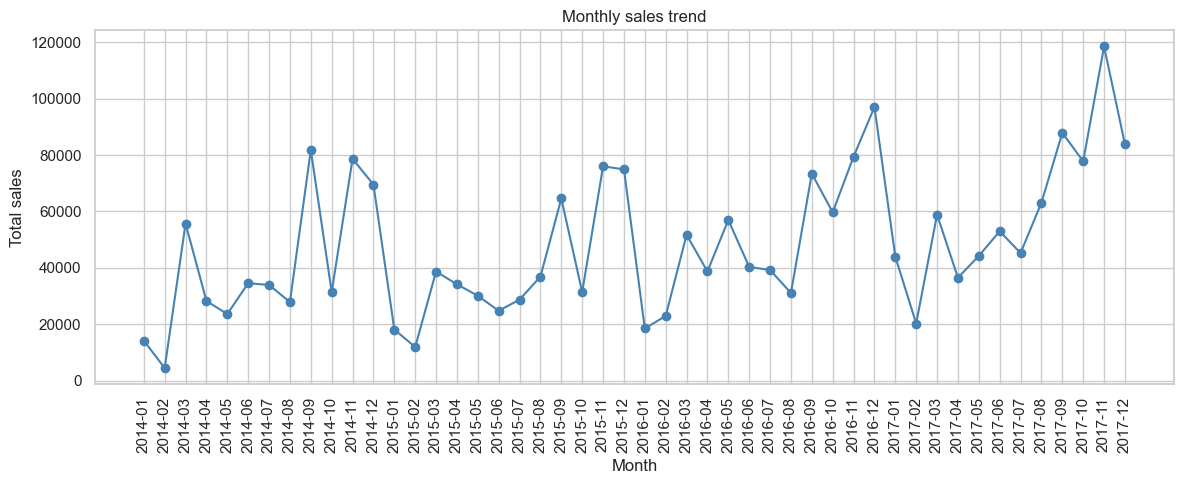

In [21]:
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()
monthly_sales["Month"] = monthly_sales["Month"].astype(str)

plt.figure()
plt.plot(monthly_sales["Month"], monthly_sales["Sales"], marker='o', color='steelblue')
plt.xticks(rotation=90)
plt.title("Monthly sales trend")
plt.xlabel("Month")
plt.ylabel("Total sales")
plt.tight_layout()
plt.show()

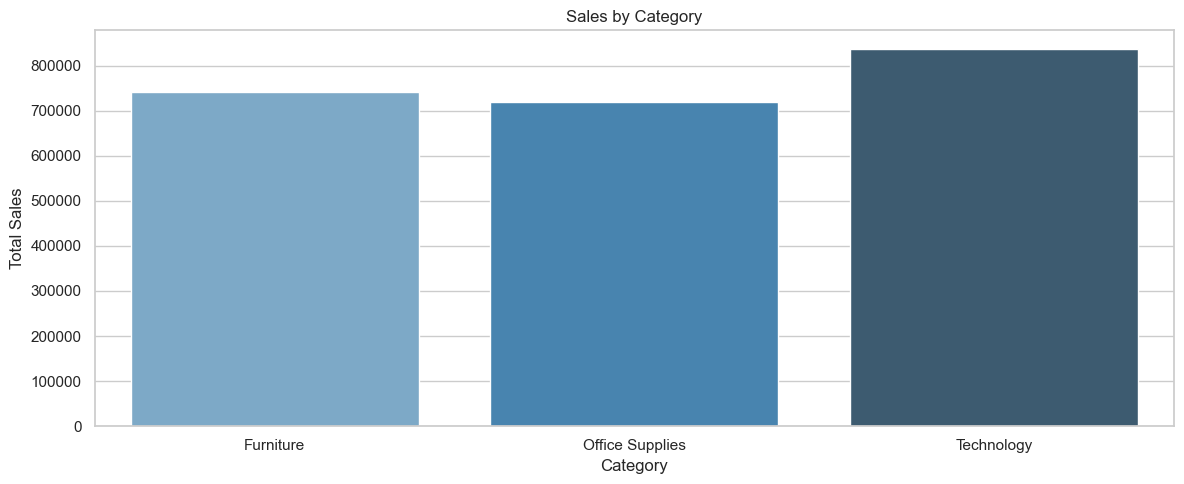

In [23]:
category_sales = df.groupby("Category")["Sales"].sum().reset_index()

plt.figure()
sns.barplot(data=category_sales, x="Category", y="Sales", hue="Category", palette="Blues_d", legend=False)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

C:\Users\Hari\AppData\Local\Temp\ipykernel_13648\3983424558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_profit, x="Region", y="Profit", palette="Greens_d")


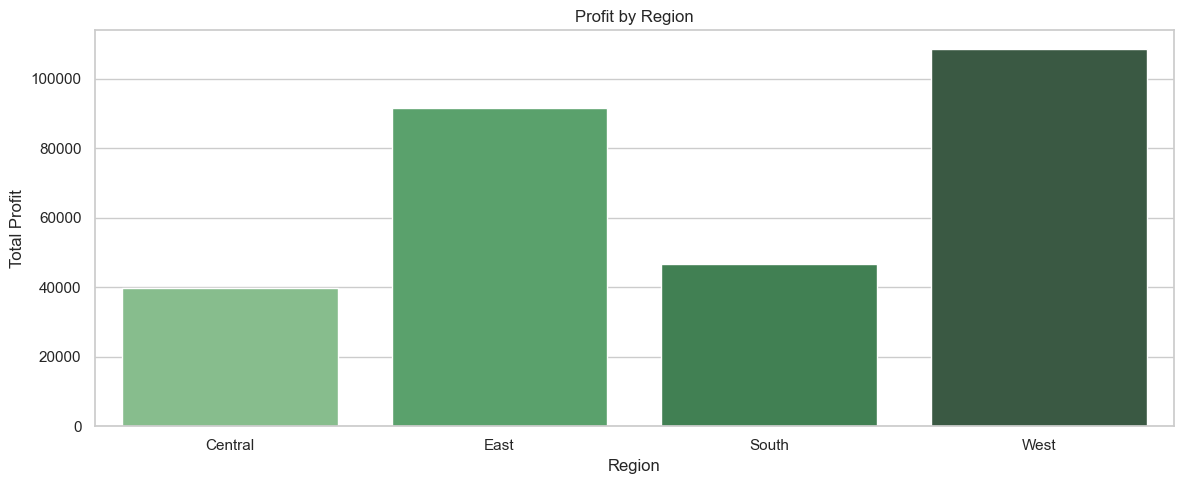

In [24]:
region_profit = df.groupby("Region")["Profit"].sum().reset_index()

plt.figure()
sns.barplot(data=region_profit, x="Region", y="Profit", palette="Greens_d")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

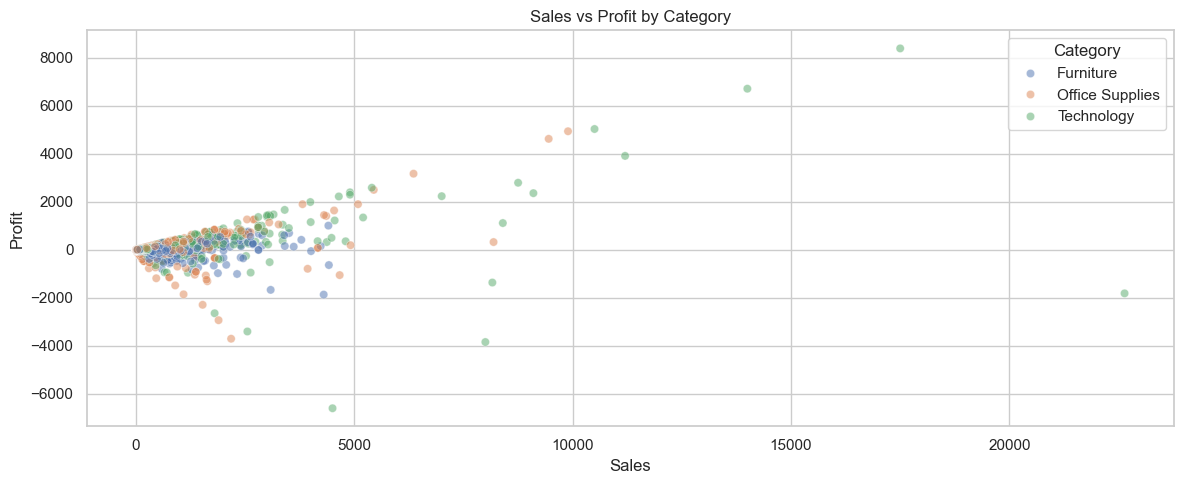

In [25]:
plt.figure()
sns.scatterplot(data=df, x="Sales", y="Profit", hue="Category", alpha=0.5)
plt.title("Sales vs Profit by Category")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

C:\Users\Hari\AppData\Local\Temp\ipykernel_13648\3983424558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_profit, x="Region", y="Profit", palette="Greens_d")


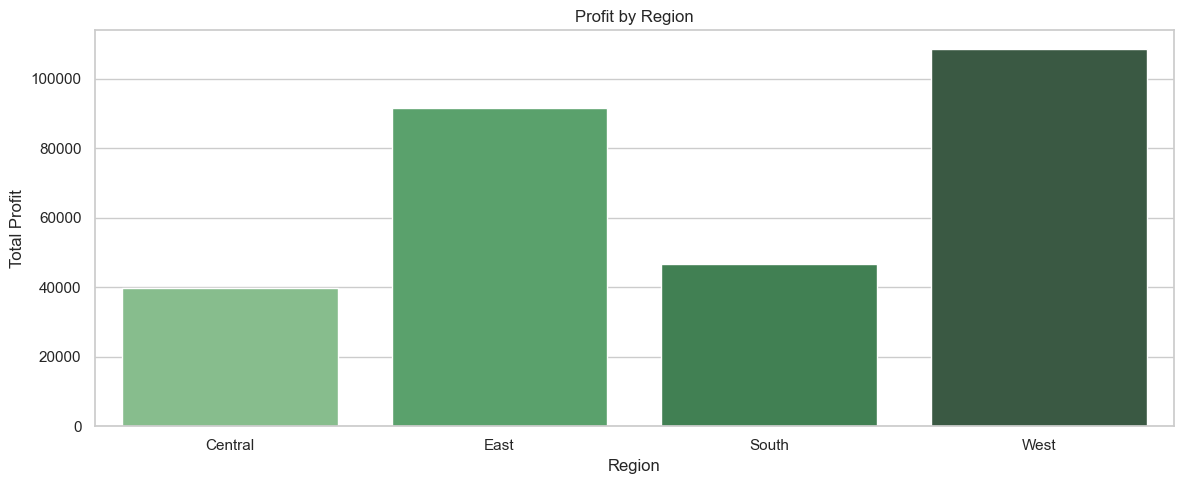

In [31]:
region_profit = df.groupby("Region")["Profit"].sum().reset_index()

plt.figure()
sns.barplot(data=region_profit, x="Region", y="Profit", palette="Greens_d")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

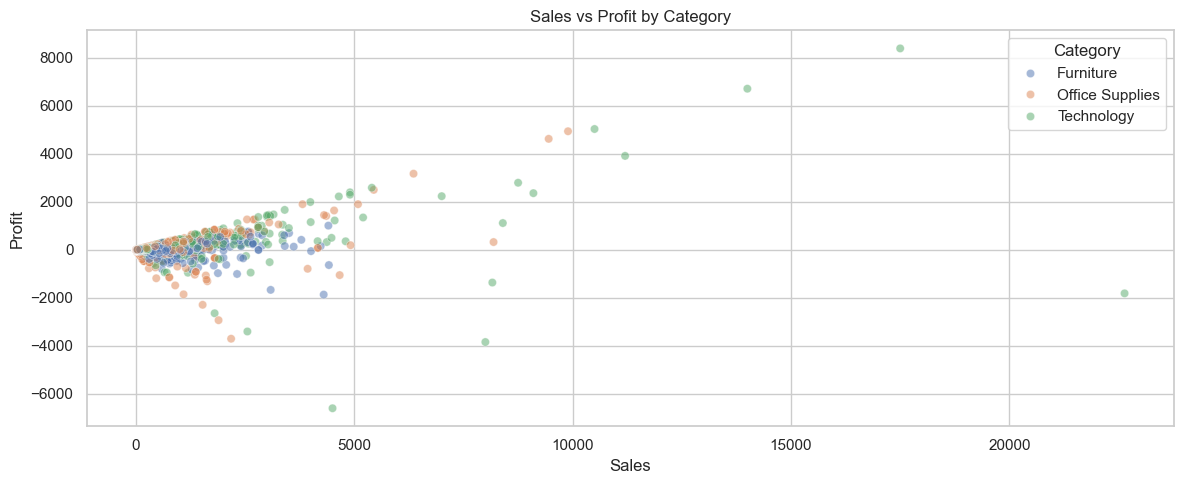

In [27]:
plt.figure()
sns.scatterplot(data=df, x="Sales", y="Profit", hue="Category", alpha=0.5)
plt.title("Sales vs Profit by Category")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

C:\Users\Hari\AppData\Local\Temp\ipykernel_13648\487868954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x="Sales", y="Product Name", palette="Oranges_d")


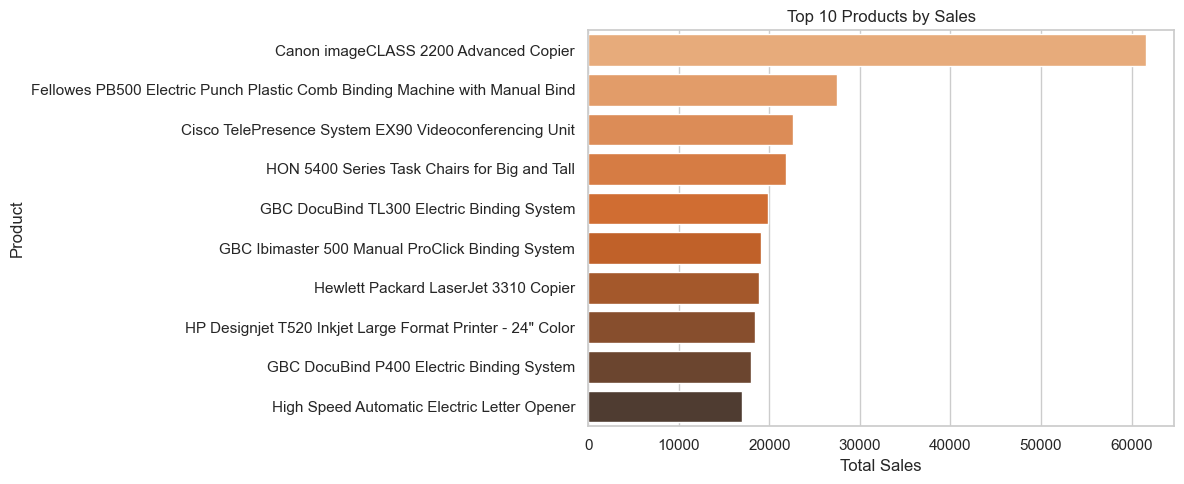

In [28]:
top_products = df.groupby("Product Name")["Sales"].sum().reset_index()
top_products = top_products.sort_values("Sales", ascending=False).head(10)

plt.figure()
sns.barplot(data=top_products, x="Sales", y="Product Name", palette="Oranges_d")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()